# Faza 2 — AI-SPEAK preprocessing po VIPL demo pipeline-u


## Goal

Pretvori `spk*/ser/video_a/*.mp4` u numerisane `128×64` mouth JPEG frejmove
koristeći brzi BlazeFace detector, isti 68-point face alignment, VIPL afinu
transformaciju i crop. Ne generiše se manifest, vocab, split ili statičan ROI.
Neuspesi ostaju u običnom logu.


## Setup

Izaberi T4 GPU. ZIP se jednom kopira sa Drive-a na `/content`; landmark obrada
sa montiranog Drive-a bi bila znatno sporija. Prilagodi samo `ZIP_ON_DRIVE`.


In [1]:
import subprocess, sys
subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-q',
     'face-alignment==1.4.1', 'editdistance>=0.8.1'],
    check=True,
)


CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', '-q', 'face-alignment==1.4.1', 'editdistance>=0.8.1'], returncode=0)

In [2]:
import os
import subprocess
from pathlib import Path

REPO_URL = 'https://github.com/nikolabakic/Vizuelno-prepoznavanje-govora-na-osnovu-pokreta-usana-pomo-u-LipNet-modela.git'
REPO = Path('/content/lipnet-serbian')
if not (REPO / 'lipnet').exists():
    subprocess.run(['git', 'clone', REPO_URL, str(REPO)], check=True)
os.chdir(REPO)
print('Repo:', REPO)
print('Commit:', subprocess.check_output(['git', 'rev-parse', 'HEAD'], text=True).strip())


Repo: /content/lipnet-serbian
Commit: 7f2e16d867b87fb75f779dc12504161360454539


In [3]:
import numpy as np
import torch
assert torch.cuda.is_available(), 'Uključi T4 GPU u Colab Runtime postavkama.'
print('GPU:', torch.cuda.get_device_name(0))


GPU: Tesla T4


In [4]:
from google.colab import drive

drive.mount('/content/drive')
DRIVE_ROOT = Path('/content/drive/MyDrive/LipNet')
DRIVE_ROOT.mkdir(parents=True, exist_ok=True)
print('Drive izlaz:', DRIVE_ROOT)


Mounted at /content/drive
Drive izlaz: /content/drive/MyDrive/LipNet


## Steps

### 1. Kopiraj i raspakuj lokalni korpus


In [5]:
import shutil
import zipfile

ZIP_ON_DRIVE = Path(
    "/content/drive/MyDrive/processed.zip"
)
LOCAL_ZIP = Path("/content/processed.zip")
EXTRACT_ROOT = Path("/content/ai_speak_source")

OUTPUT_ROOT = Path(
    "/content/ai_speak_lip_blazeface"
)
CHECKPOINT_DIR = (
    DRIVE_ROOT / "phase2_chunks_blazeface"
)

RUN_FULL_PREPROCESSING = True

assert ZIP_ON_DRIVE.exists(), ZIP_ON_DRIVE

# Ponovo kopiraj ZIP ako lokalna kopija nedostaje ili nije ispravna.
if (
    not LOCAL_ZIP.exists()
    or not zipfile.is_zipfile(LOCAL_ZIP)
):
    if LOCAL_ZIP.exists():
        LOCAL_ZIP.unlink()

    print("Kopiram processed.zip sa Drive-a...")
    shutil.copy2(ZIP_ON_DRIVE, LOCAL_ZIP)

assert zipfile.is_zipfile(LOCAL_ZIP), (
    f"Nije ispravna ZIP arhiva: {LOCAL_ZIP}"
)

# Nije dovoljno proveriti samo da direktorijum postoji.
EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)

alignment = next(
    EXTRACT_ROOT.rglob("spk*/alignment/*.align"),
    None,
)

if alignment is None:
    print(
        "AI-SPEAK sadržaj nije pronađen; "
        "raspakujem processed.zip..."
    )

    with zipfile.ZipFile(LOCAL_ZIP) as archive:
        archive.extractall(EXTRACT_ROOT)

    alignment = next(
        EXTRACT_ROOT.rglob("spk*/alignment/*.align"),
        None,
    )

assert alignment is not None, (
    "Posle raspakivanja nema "
    f"spk*/alignment/*.align u {EXTRACT_ROOT}. "
    "Proveri strukturu processed.zip arhive."
)

CORPUS_ROOT = alignment.parents[2]

videos = list(
    CORPUS_ROOT.glob("spk*/ser/video_a/*.mp4")
)
annotations = list(
    CORPUS_ROOT.glob("spk*/alignment/*.align")
)

assert videos, "Nisu pronađeni MP4 fajlovi."
assert len(videos) == len(annotations), (
    len(videos),
    len(annotations),
)

print("Korpus:", CORPUS_ROOT)
print("MP4/ALIGN:", len(videos), len(annotations))

# Vrati završene BlazeFace checkpoint blokove sa Drive-a.
CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

checkpoint_archives = sorted(
    CHECKPOINT_DIR.glob("chunk_*.zip")
)

if (
    checkpoint_archives
    and not next(
        OUTPUT_ROOT.glob("spk*/video/video_a/*"),
        None,
    )
):
    OUTPUT_ROOT.mkdir(
        parents=True,
        exist_ok=True,
    )

    for index, checkpoint in enumerate(
        checkpoint_archives,
        start=1,
    ):
        with zipfile.ZipFile(checkpoint) as archive:
            archive.extractall(OUTPUT_ROOT)

        if (
            index % 25 == 0
            or index == len(checkpoint_archives)
        ):
            print(
                "Vraćeni checkpoint-i:",
                f"{index}/{len(checkpoint_archives)}",
            )

restored_samples = len(
    list(
        OUTPUT_ROOT.glob(
            "spk*/video/video_a/*"
        )
    )
)

print(
    "Vraćeno/zatečeno gotovih sample foldera:",
    restored_samples,
)

Kopiram processed.zip sa Drive-a...
AI-SPEAK sadržaj nije pronađen; raspakujem processed.zip...
Korpus: /content/ai_speak_source/processed
MP4/ALIGN: 3957 3957
Vraćeni checkpoint-i: 25/186
Vraćeni checkpoint-i: 50/186
Vraćeni checkpoint-i: 75/186
Vraćeni checkpoint-i: 100/186
Vraćeni checkpoint-i: 125/186
Vraćeni checkpoint-i: 150/186
Vraćeni checkpoint-i: 175/186
Vraćeni checkpoint-i: 186/186
Vraćeno/zatečeno gotovih sample foldera: 1860


### 2. Prvo uradi jedan GPU smoke primer i upstream `_load_vid` proveru


In [6]:
SMOKE_ROOT = Path('/content/ai_speak_lip_blazeface_smoke')
smoke_command = [
    sys.executable, '-m', 'scripts.prepare_ai_speak',
    '--corpus', str(CORPUS_ROOT), '--output', str(SMOKE_ROOT),
    '--device', 'cuda', '--face-detector', 'blazeface', '--limit', '1',
]
print('Pokrećem:', ' '.join(smoke_command))
smoke = subprocess.run(smoke_command, text=True, capture_output=True)
print(smoke.stdout)
if smoke.returncode:
    print(smoke.stderr)
    raise RuntimeError(
        f'AI-SPEAK smoke preprocessing nije uspeo (exit={smoke.returncode}). '
        'Stvarna greška je odštampana neposredno iznad.'
    )

from lipnet.dataset import MyDataset
sample_folder = next(SMOKE_ROOT.glob('spk*/video/video_a/*'))
sample_array = MyDataset._load_vid(sample_folder)
normalized = sample_array / 255.0
assert sample_array.shape[1:] == (64, 128, 3)
assert 0.0 <= float(normalized.min()) <= float(normalized.max()) <= 1.0
print('VIPL _load_vid:', sample_array.shape, 'range:', normalized.min(), normalized.max())


Pokrećem: /usr/bin/python3 -m scripts.prepare_ai_speak --corpus /content/ai_speak_source/processed --output /content/ai_speak_lip_blazeface_smoke --device cuda --face-detector blazeface --limit 1
Pronađeno 1 uparenih klipova
Downloading: "https://github.com/hollance/BlazeFace-PyTorch/blob/master/blazeface.pth?raw=true" to /root/.cache/torch/hub/checkpoints/blazeface.pth
Preprocessing 1/1 | uspešno=1 | neuspešno=0
Frejmovi: /content/ai_speak_lip_blazeface_smoke
QA: /content/ai_speak_lip_blazeface_smoke/qa_mouth_crops.jpg
Neuspeli klipovi: /content/ai_speak_lip_blazeface_smoke/failed_clips.log

VIPL _load_vid: (130, 64, 128, 3) range: 0.007843138 0.9098039


### 3. Obradi ceo korpus na GPU-u i nastavi bez ponavljanja gotovih klipova


In [7]:
%cd /content/lipnet-serbian

!python -m scripts.prepare_ai_speak --help

/content
usage: prepare_ai_speak.py [-h] --corpus CORPUS --output OUTPUT
                           [--device DEVICE]
                           [--face-detector {sfd,blazeface,retinaface}]
                           [--speakers [SPEAKERS ...]] [--limit LIMIT]
                           [--resume] [--report-every REPORT_EVERY]
                           [--checkpoint-dir CHECKPOINT_DIR]
                           [--checkpoint-every CHECKPOINT_EVERY]

Convert AI-SPEAK MP4 files to VIPL-compatible mouth JPEG folders. This is
intentionally a thin corpus loop around ``lipnet.demo``. It writes no training
manifest and no static ROI. Run it on a Colab GPU; the script itself never
selects or installs a CUDA runtime.

options:
  -h, --help            show this help message and exit
  --corpus CORPUS
  --output OUTPUT
  --device DEVICE
  --face-detector {sfd,blazeface,retinaface}
  --speakers [SPEAKERS ...]
  --limit LIMIT
  --resume
  --report-every REPORT_EVERY
  --checkpoint-dir CHECKPOINT_

In [8]:
%cd /content/lipnet-serbian

import subprocess

subprocess.run(
    ["git", "pull", "--ff-only"],
    check=True,
)

subprocess.run(
    [
        sys.executable,
        "-m",
        "scripts.prepare_ai_speak",
        "--help",
    ],
    check=True,
)

/content


CompletedProcess(args=['/usr/bin/python3', '-m', 'scripts.prepare_ai_speak', '--help'], returncode=0)

In [9]:
if RUN_FULL_PREPROCESSING:
    subprocess.run([
        sys.executable, '-m', 'scripts.prepare_ai_speak',
        '--corpus', str(CORPUS_ROOT), '--output', str(OUTPUT_ROOT),
        '--device', 'cuda', '--face-detector', 'blazeface', '--resume',
        '--report-every', '5',
        '--checkpoint-dir', str(CHECKPOINT_DIR),
        '--checkpoint-every', '10',
    ], check=True)
else:
    print('RUN_FULL_PREPROCESSING=False: ceo GPU posao je namerno preskočen.')


## Checks

### 4. Vizuelno pregledaj normalne i granične klipove svakog govornika


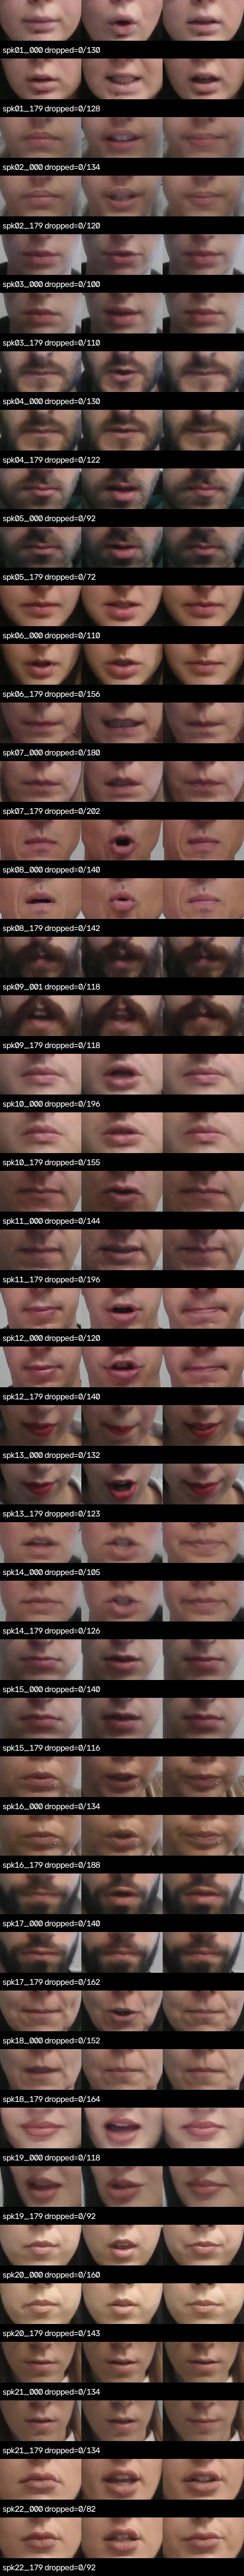

Neuspeli klipovi: 0
Nema neuspelih klipova.
Ručno potvrdi: usne su u centru, nisu odsečene i crop je stabilan.


In [10]:
from IPython.display import Image, display

QA_PATH = OUTPUT_ROOT / 'qa_mouth_crops.jpg'
FAILURE_LOG = OUTPUT_ROOT / 'failed_clips.log'
assert QA_PATH.exists(), 'Puna obrada nije napravljena ili nije završena.'
display(Image(filename=str(QA_PATH)))
failures = FAILURE_LOG.read_text(encoding='utf-8').strip().splitlines()
print('Neuspeli klipovi:', len([line for line in failures if line]))
print('\n'.join(failures[:20]) if failures else 'Nema neuspelih klipova.')
print('Ručno potvrdi: usne su u centru, nisu odsečene i crop je stabilan.')


### 5. Arhiviraj JPEG foldere i logove na Drive


In [11]:
if RUN_FULL_PREPROCESSING:
    archive_base = Path('/content/ai_speak_lip')
    archive = Path(shutil.make_archive(str(archive_base), 'zip', root_dir=OUTPUT_ROOT))
    drive_archive = DRIVE_ROOT / 'ai_speak_lip.zip'
    shutil.copy2(archive, drive_archive)
    print('Sačuvano:', drive_archive, f'{drive_archive.stat().st_size/1024**3:.2f} GiB')


Sačuvano: /content/drive/MyDrive/LipNet/ai_speak_lip.zip 1.34 GiB


## Next Steps

Ne prelazi na Dataset dok smoke shape/opseg i ručni QA ne prođu. Faza 3 čita samo
JPEG foldere i originalne `.align` fajlove; `preprocessing.jsonl` i failure log nisu
ulaz u trening.
